<h1>Train — ResNet-18 (baseline)</h1>

Trains and evaluates the ResNet-18 baseline classifier, then saves its results (`results_resnet18.pkl`) and weights (`{COMPONENT}_resnet18_cnn.pt`) to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1850 | Val: 405 | Test: 252


## Define the model (Transfer Learning with ResNet-18)

In [2]:
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)  # no hidden layers — this one predates the tuning sweep

model_resnet18 = model_resnet18.to(device)

# ---------------------------------------------------------
# Loss and optimizer, with class weights for the imbalanced classes
# ---------------------------------------------------------
class_weights = make_class_weights(train_ds)
print("Applying class weights to loss function:")
for name, w in zip(class_names, class_weights.cpu().numpy()):
    print(f"  {name:<15s}: {w:.3f}")

criterion_resnet18 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet18 = optim.Adam(model_resnet18.parameters(), lr=5e-4, weight_decay=WEIGHT_DECAY)

# mode='min' because we want to minimize loss; factor=0.5 halves the LR when
# triggered; patience=3 waits 3 epochs with no improvement before reducing it
scheduler_resnet18 = ReduceLROnPlateau(optimizer_resnet18, mode='min', factor=0.5, patience=3)

Applying class weights to loss function:
  Dysfunctional  : 1.109
  Empty          : 2.209
  Functional     : 0.307
  Scum           : 0.374


## Train, then plot training curves

[ResNet-18] Epoch   1/100 | LR: 5.00e-04 | train loss 0.9839 acc 0.564 | val loss 0.7536 acc 0.723 *
[ResNet-18] Epoch   2/100 | LR: 5.00e-04 | train loss 0.7126 acc 0.659 | val loss 0.9446 acc 0.600
[ResNet-18] Epoch   3/100 | LR: 5.00e-04 | train loss 0.6562 acc 0.685 | val loss 0.7970 acc 0.748
[ResNet-18] Epoch   4/100 | LR: 5.00e-04 | train loss 0.5566 acc 0.751 | val loss 0.8025 acc 0.664
[ResNet-18] Epoch   5/100 | LR: 2.50e-04 | train loss 0.5215 acc 0.765 | val loss 0.9475 acc 0.709
[ResNet-18] Epoch   6/100 | LR: 2.50e-04 | train loss 0.4268 acc 0.800 | val loss 1.0378 acc 0.706
[ResNet-18] Epoch   7/100 | LR: 2.50e-04 | train loss 0.3788 acc 0.814 | val loss 1.0583 acc 0.689
[ResNet-18] Epoch   8/100 | LR: 2.50e-04 | train loss 0.3632 acc 0.826 | val loss 1.2313 acc 0.669
[ResNet-18] Epoch   9/100 | LR: 1.25e-04 | train loss 0.3457 acc 0.835 | val loss 0.8453 acc 0.763
[ResNet-18] Epoch  10/100 | LR: 1.25e-04 | train loss 0.2519 acc 0.872 | val loss 1.1845 acc 0.699
[ResNet-

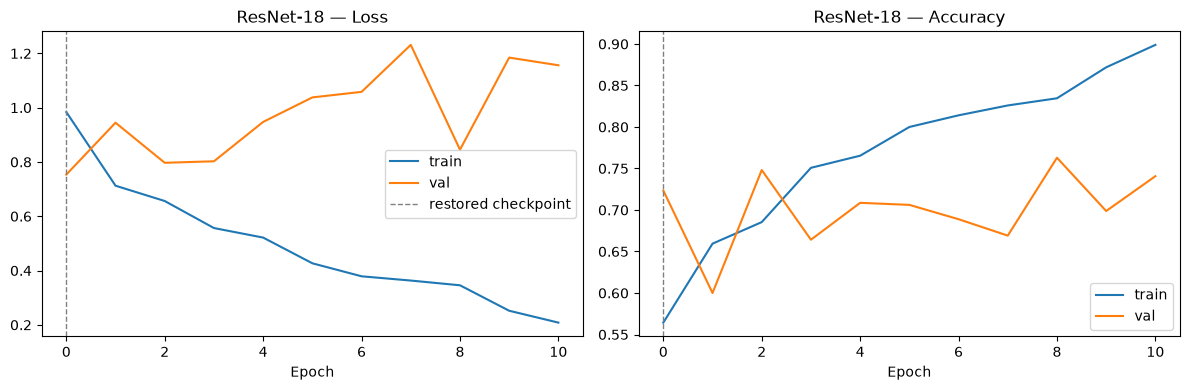

In [3]:
history_resnet18 = train_model(
    model_resnet18, train_loader, val_loader, optimizer_resnet18, scheduler_resnet18,
    criterion_resnet18, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18",
)
plot_training_curves(history_resnet18, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.508


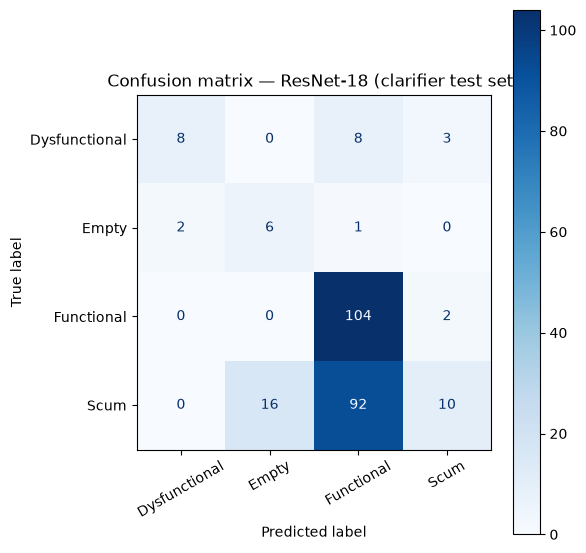

               precision    recall  f1-score   support

Dysfunctional      0.800     0.421     0.552        19
        Empty      0.273     0.667     0.387         9
   Functional      0.507     0.981     0.669       106
         Scum      0.667     0.085     0.150       118

     accuracy                          0.508       252
    macro avg      0.562     0.538     0.440       252
 weighted avg      0.596     0.508     0.407       252



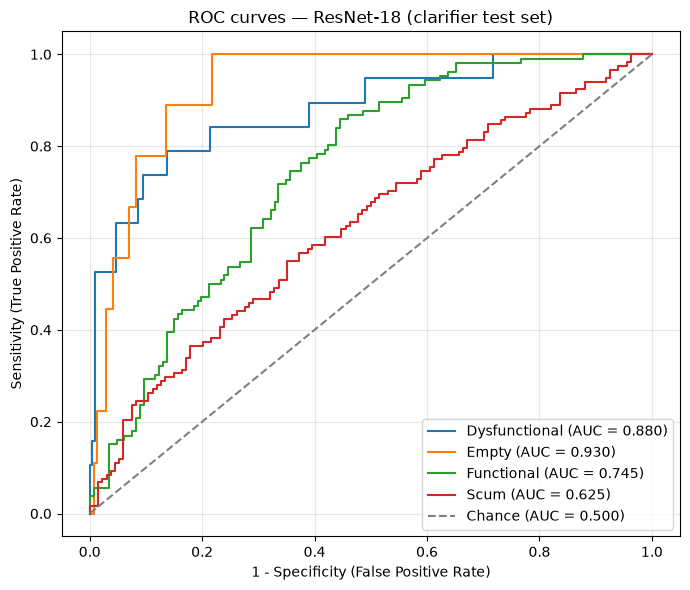

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.880
  Empty          : 0.930
  Functional     : 0.745
  Scum           : 0.625

Mean AUC: 0.795


(np.float64(0.5079365079365079),
 {'Dysfunctional': 0.8796024395753331,
  'Empty': 0.9304983996342021,
  'Functional': 0.745347635047816,
  'Scum': 0.6250316215532508})

In [4]:
evaluate_and_record(
    model_resnet18, test_loader, "ResNet-18", history_resnet18,
    img_size=IMG_TARGET_SIZE, hidden_layers=0, neurons=None,
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [5]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_clarifier_resnet18.pkl
Saved model weights to ../models/clarifier_resnet18_cnn.pt
